In [1]:
import os
from pathlib import Path

import polars as pl
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import mllabs 
mllabs.__version__

2026-05-31 20:32:16.305216: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-31 20:32:16.338632: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-31 20:32:17.344408: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/sun9sun9/python312/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: Fu

'0.8.0'

In [2]:
from mllabs.processor import PolarsLoader, PandasConverter, ExprProcessor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

data_path = Path('data')

ploader = PolarsLoader(predefined_types={'id': pl.Int64, 'PitNextLap': pl.Float32})
ploader.fit([data_path / 'train.csv', data_path / 'test.csv', data_path / 'f1_strategy_dataset_v4.csv'])

pconv = PandasConverter(index_col= 'id')
expr_dict = {
    'Position_Change': pl.col('Position_Change').cast(pl.Int8),
}
expr_proc = ExprProcessor(expr_dict)

df_train = pconv.fit_transform(
    expr_proc.fit_transform(ploader.transform([data_path / 'train.csv']))
)
df_train.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
id,,,,,,,,,,,,,,,
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.490997,-7.564000,21.018999,0.714286,5,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095001,-32.617001,-223.207001,0.346154,-3,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945000,-7.540000,-100.528999,0.819444,3,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361000,-7.324000,-7.324000,0.076923,0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.877998,8.965000,-14.139000,0.361111,3,0.0


In [3]:
loader = make_pipeline(ploader, expr_proc, pconv)
df_test = loader.transform([data_path / 'test.csv'])
df_org = loader.transform([data_path / 'f1_strategy_dataset_v4.csv']).pipe(
    lambda x: x.set_index(pd.Index(x.index + 1, name = 'id'))
)

In [4]:
df_train.shape, df_org.shape, df_test.shape

((439140, 15), (101371, 16), (188165, 14))

In [5]:
df_train['PitNextLap'] = df_train['PitNextLap'].astype('int8')
df_org['PitNextLap'] = df_org['PitNextLap'].astype('int8')

In [6]:
X_bin = ['PitStop']
X_nom = ['Driver', 'Compound', 'Race', 'Year']
X_int = ['LapNumber', 'Stint', 'Position', 'Position_Change']
X_cont = ['TyreLife', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress']
y = 'PitNextLap'

In [7]:
s_lap_progress = pd.concat([
    df_train.loc[(df_train['LapNumber'] == 1) & (df_train['TyreLife'] == 1.0)], 
    df_test.loc[(df_test['LapNumber'] == 1) & (df_test['TyreLife'] == 1.0)]
]).groupby('Race')['RaceProgress'].apply(lambda x: x.mode()[0])
s_total_lap = (1 / s_lap_progress).round()
df_drv = pd.concat([
    df_train[['Driver', 'Position']], df_test[['Driver', 'Position']]
])

df_drv_stat = df_drv.groupby('Driver')['Position'].agg(['mean', 'count']).rename(columns={'mean': 'Drv_Position_mean', 'count': 'Drv_count'})

In [8]:
def process(df):
    return df.join(df_drv_stat).assign(
        Total_Lap = lambda x: x['Race'].map(s_total_lap),
        TyreLife2 = lambda x: x['TyreLife'] / x['Total_Lap'],
        TyreLife3 = lambda x: x['RaceProgress'] / x['LapNumber'] * x['TyreLife'],
        diff = lambda x: x['LapNumber'] - x['TyreLife'],
        RaceProgress2 = lambda x: x['Race'].map(s_lap_progress) * x['LapNumber'],
        diff2 = lambda x: x['RaceProgress2'] - x['RaceProgress'],
        LapNumber2 = lambda x: x['RaceProgress'] * x['Total_Lap'],
        diff3 = lambda x: x['LapNumber'] - x['LapNumber2'],
        diff_Position = lambda x: x['Position'] - x['Drv_Position_mean']
    )

In [9]:
df_train = process(df_train)
df_test = process(df_test)

In [10]:
df_tmp = pd.concat([
    df_train[['Compound', 'TyreLife3']],
    df_test[['Compound', 'TyreLife3']]
], axis=0).groupby('Compound')['TyreLife3'].transform(lambda x: (x - x.mean()) / x.std())
df_train['TyreLife3_Compound_norm'] = df_tmp.loc[df_train.index]
df_test['TyreLife3_Compound_norm'] = df_tmp.loc[df_test.index]

In [11]:
X_ext_num = ['Total_Lap', 'TyreLife2', 'TyreLife3', 'diff', 'RaceProgress2', 'diff2', 'LapNumber2', 'diff3', 'diff_Position', 'TyreLife3_Compound_norm',
            'Drv_Position_mean', 'Drv_count']
X_all = X_bin + X_nom + X_int + X_cont + X_ext_num

In [12]:
import lightgbm as lgb
from sklearn.model_selection import cross_validate, ShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ss = ShuffleSplit(1, random_state = 123)

In [13]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([5.68662977]),
 'score_time': array([0.21454978]),
 'test_score': array([0.95128449]),
 'train_score': array([0.9646913])}

In [14]:
df_train['LapNumber2_i'] = df_train['LapNumber2'].round().astype('int')

In [15]:
q_val = pd.concat([df_train['RaceProgress'], df_test['RaceProgress']]).quantile(q = np.arange(0, 21) / 20)
q_val

0.00    0.012821
0.05    0.027778
0.10    0.052632
0.15    0.076923
0.20    0.098592
0.25    0.128571
0.30    0.153846
0.35    0.179487
0.40    0.207792
0.45    0.236842
0.50    0.269231
0.55    0.307692
0.60    0.358974
0.65    0.407895
0.70    0.461538
0.75    0.513158
0.80    0.576923
0.85    0.641509
0.90    0.722222
0.95    0.842105
1.00    1.000000
Name: RaceProgress, dtype: float64

In [16]:
df_train['RaceProgress_q1'] = pd.cut(df_train['RaceProgress'], q_val)
df_test['RaceProgress_q1'] = pd.cut(df_test['RaceProgress'], q_val)

In [17]:
df_train['Compound2'] = df_train['Compound'].replace({'WET': 'SOFT', 'INTERMEDIATE': 'MEDIUM'})
df_test['Compound2'] = df_test['Compound'].replace({'WET': 'SOFT', 'INTERMEDIATE': 'MEDIUM'})

- Race 진행에 따라 LapTime_Delta 와 Cumulative_Degradation은 달라지니, 이에 대한 정규화를 합니다.

In [19]:
df_timedelta_std = pd.concat([
    df_train[['RaceProgress_q1', 'LapTime_Delta', 'Cumulative_Degradation']],
    df_test[['RaceProgress_q1', 'LapTime_Delta', 'Cumulative_Degradation']]
]).groupby(['RaceProgress_q1'])[['LapTime_Delta', 'Cumulative_Degradation']].transform(
    lambda x: (x - x.mean()) / x.std()).rename(columns = lambda x: x + '_std')
df_train = df_train.join(df_timedelta_std)

In [20]:
X_timedelta_std = df_timedelta_std.columns.tolist()
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'] + X_timedelta_std)
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_train[X_all + X_timedelta_std], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(array([0.95153063]), array([0.9650935]))

In [21]:
pd.Series(
    result['estimator'][0][1].feature_importances_, index = result['estimator'][0][0].get_feature_names_out()
).sort_values(ascending = False).iloc[:20]

pt__LapTime (s)                   4033
pt__Cumulative_Degradation        3640
pt__LapTime_Delta                 3143
pt__Cumulative_Degradation_std    2833
pt__Position                      2543
pt__LapTime_Delta_std             2436
pt__Position_Change               2300
pt__diff                          2157
pt__diff2                         2153
pt__TyreLife3_Compound_norm       2022
pt__RaceProgress                  1606
pt__TyreLife3                     1428
pt__diff3                         1281
pt__LapNumber2                    1174
pt__TyreLife2                     1123
pt__RaceProgress2                 1008
pt__Stint                          939
pt__LapNumber                      889
pt__TyreLife                       787
pt__PitStop                        466
dtype: int32

- 레이스 코스에 따라 Laptime이 달라질테니 이에 대한 정규화를 합니다.

In [24]:
df_time_std = pd.concat([
    df_train[['Race', 'LapTime (s)']],
    df_test[['Race', 'LapTime (s)']]
]).groupby(['Race'])[['LapTime (s)']].transform(
    lambda x: (x - x.clip(*x.quantile([0.01, 0.99])).mean()) / x.clip(*x.quantile([0.01, 0.99])).std()).rename(columns = lambda x: x + '_std')
df_train = df_train.join(df_time_std)

In [25]:
X_time_std = df_time_std.columns.tolist()
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'] + X_timedelta_std + X_time_std)
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_train[X_all + X_timedelta_std + X_time_std], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(array([0.95139978]), array([0.96529514]))

In [26]:
df_train['Stint2'] = df_train['Stint'].clip(1, 5)
df_test['Stint2'] = df_train['Stint'].clip(1, 5)

- Stint가 빈도가 적은 5이상을 잘라냅니다. 이에 대한 영향을 봅니다.

In [27]:
X_timedelta_std = df_timedelta_std.columns.tolist()
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint2', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'] + X_timedelta_std)
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_train[X_all + X_timedelta_std + ['Stint2']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(array([0.95138709]), array([0.9649316]))

- 약간의 성능 저하가 있지만 쓸 경우에 따라 축약한 속성을 쓸만합니다.

In [115]:
s_mean_tyrelife = pd.concat([
    df_train.loc[df_train['PitStop'] == 1],
    df_test.loc[df_test['PitStop'] == 1]
]).groupby(
    ['Compound', 'Stint2']
)[['TyreLife2', 'TyreLife3', 'Cumulative_Degradation', 'LapTime_Delta']].agg(lambda x: x.clip(*x.quantile([0.01, 0.99])).mean()).rename(columns = lambda x: x + '_mean')

In [116]:
df_train = df_train.drop(columns=s_mean_tyrelife.columns).join(s_mean_tyrelife, on = ['Compound', 'Stint2'])

In [117]:
df_train['TyreLife_Ratio'] = df_train['TyreLife3'] / df_train['TyreLife3_mean']
df_train['Cumulative_Degradation_Ratio'] = df_train['Cumulative_Degradation'] / df_train['Cumulative_Degradation_mean']
df_train['LapTime_Delta_Ratio'] = df_train['LapTime_Delta'] / df_train['LapTime_Delta_mean']

In [118]:
X_ratio = ['TyreLife_Ratio', 'Cumulative_Degradation_Ratio', 'LapTime_Delta_Ratio']
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'] + X_timedelta_std + X_ratio)
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_train[X_all + X_timedelta_std + X_ratio], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(array([0.95135044]), array([0.96539078]))

In [119]:
pd.Series(
    result['estimator'][0][1].feature_importances_, index = result['estimator'][0][0].get_feature_names_out()
).sort_values(ascending = False).iloc[:20]

pt__LapTime (s)                     3710
pt__Cumulative_Degradation_Ratio    2797
pt__Cumulative_Degradation          2560
pt__Position                        2450
pt__Cumulative_Degradation_std      2235
pt__LapTime_Delta                   2173
pt__diff2                           2129
pt__LapTime_Delta_Ratio             2114
pt__Position_Change                 2075
pt__diff                            1937
pt__LapTime_Delta_std               1933
pt__TyreLife3_Compound_norm         1596
pt__TyreLife_Ratio                  1575
pt__RaceProgress                    1470
pt__diff3                           1142
pt__LapNumber2                      1087
pt__TyreLife3                       1054
pt__RaceProgress2                    976
pt__TyreLife2                        937
pt__LapNumber                        727
dtype: int32

In [120]:
df_train['TyreLife_diff'] = df_train['TyreLife3'] - df_train['TyreLife3_mean']
df_train['Cumulative_Degradation_diff'] = df_train['Cumulative_Degradation'] - df_train['Cumulative_Degradation_mean']
df_train['LapTime_Delta_diff'] = df_train['LapTime_Delta'] - df_train['LapTime_Delta_mean']

In [121]:
X_diff = ['TyreLife_diff', 'Cumulative_Degradation_diff', 'LapTime_Delta_diff']
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'] + X_timedelta_std + X_diff)
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_train[X_all + X_timedelta_std + X_diff], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(array([0.95167358]), array([0.96547926]))

In [91]:
pd.Series(
    result['estimator'][0][1].feature_importances_, index = result['estimator'][0][0].get_feature_names_out()
).sort_values(ascending = False).iloc[:20]

pt__LapTime (s)                    3775
pt__Cumulative_Degradation_diff    2852
pt__Cumulative_Degradation         2543
pt__LapTime_Delta                  2453
pt__Position                       2403
pt__Cumulative_Degradation_std     2193
pt__Position_Change                2191
pt__diff2                          2051
pt__diff                           1990
pt__LapTime_Delta_std              1959
pt__LapTime_Delta_diff             1801
pt__TyreLife3_Compound_norm        1584
pt__RaceProgress                   1458
pt__TyreLife_diff                  1450
pt__diff3                          1154
pt__TyreLife3                      1054
pt__LapNumber2                     1035
pt__TyreLife2                       996
pt__RaceProgress2                   922
pt__Stint                           791
dtype: int32

In [61]:
df_train['Remain_Lap'] = df_train['Total_Lap'] - df_train['LapNumber']
df_train['Remain_Lap2'] = df_train['Total_Lap'] - df_train['LapNumber2']
df_train['TyreLife_eq_LapNumber'] = df_train['TyreLife'] == df_train['LapNumber']

In [87]:
X_feat = X_diff + ['Remain_Lap', 'Remain_Lap2', 'TyreLife_eq_LapNumber']
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'] + X_timedelta_std + X_feat)
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_train[X_all + X_timedelta_std + X_feat], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(array([0.9514134]), array([0.96546693]))

In [128]:
df_train['RaceProgress3'] = df_train['RaceProgress2'].clip(0, 1)

In [132]:
X_feat = X_diff + ['RaceProgress3']
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'] + X_timedelta_std + X_feat)
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_train[X_all + X_timedelta_std + X_feat], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(array([0.95168861]), array([0.96550582]))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

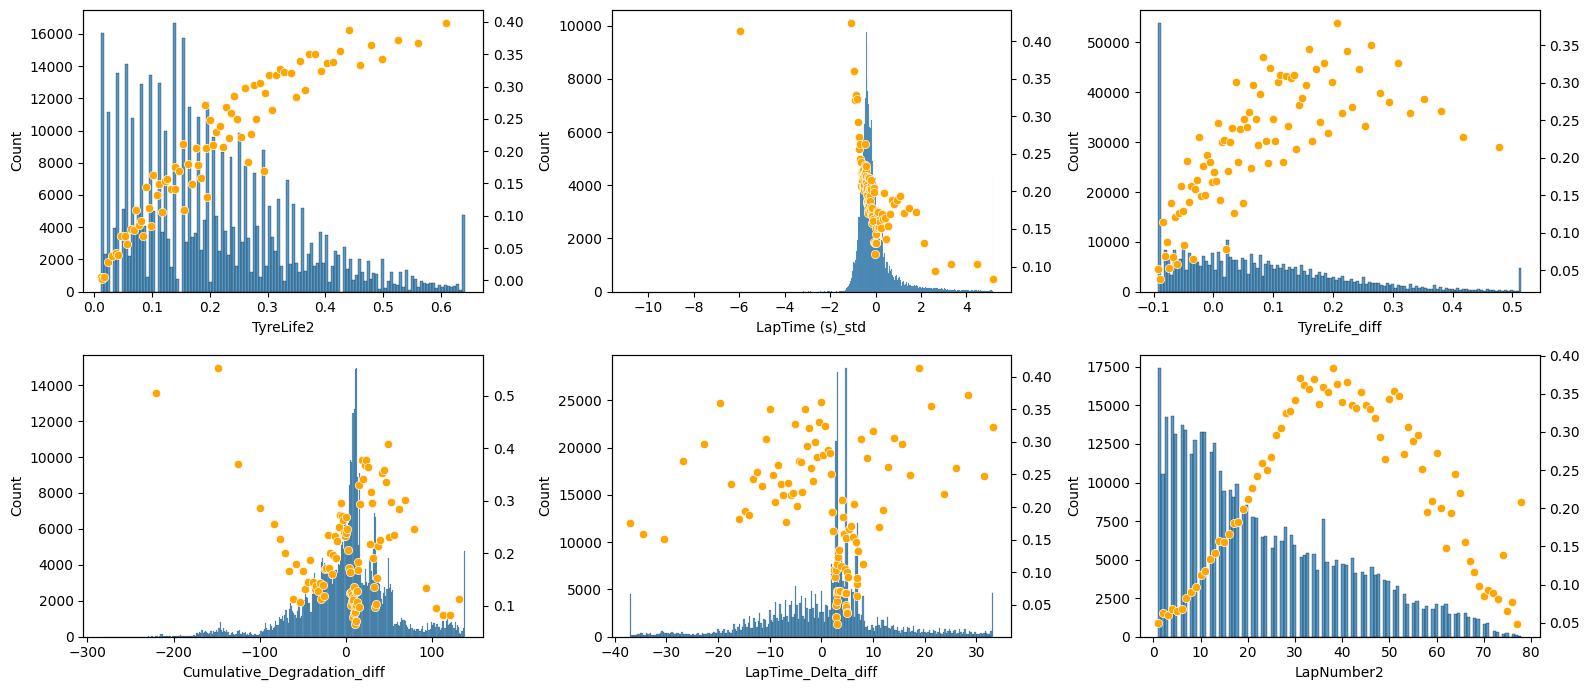

In [99]:
fig, axes = plt.subplots(2, 3, figsize = (16, 7))
axes = axes.flatten()
ax = axes[0]
v = df_train['TyreLife2'].pipe(lambda x: x.clip(*x.quantile([0, 0.99])))
sns.histplot(v, ax=ax)
df_train.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[1]
v = df_train['LapTime (s)_std'].pipe(lambda x: x.clip(*x.quantile([0, 0.99])))
sns.histplot(v, ax=ax)
df_train.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[2]
v = df_train['TyreLife_diff'].pipe(lambda x: x.clip(*x.quantile([0.1, 0.99])))
sns.histplot(v, ax=ax)
df_train.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[3]
v = df_train['Cumulative_Degradation_diff'].pipe(lambda x: x.clip(*x.quantile([0.0, 0.99])))
sns.histplot(v, ax=ax)
df_train.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[4]
v = df_train['LapTime_Delta_diff'].pipe(lambda x: x.clip(*x.quantile([0.01, 0.99])))
sns.histplot(v, ax=ax)
df_train.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[5]
v = df_train['LapNumber2'].round()
sns.histplot(v, ax=ax)
df_train.groupby(v)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax = ax.twinx())
)
plt.tight_layout()
plt.show()

<Axes: xlabel='TyreLife'>

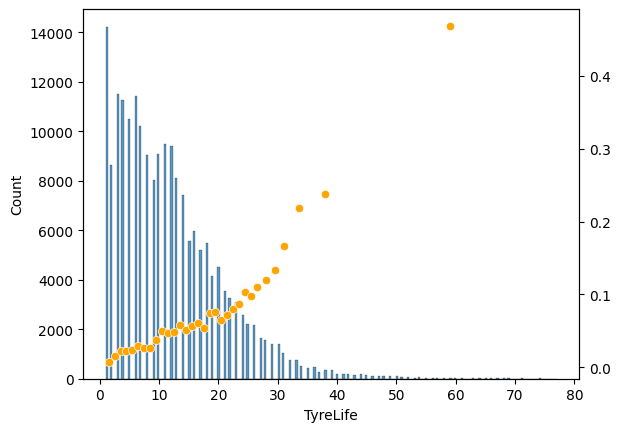

In [134]:
v = df_train.loc[df_train['TyreLife'] == df_train['LapNumber'], 'TyreLife']
ax = plt.gca()
sns.histplot(v, ax=ax)
df_train.loc[df_train['TyreLife'] == df_train['LapNumber']].groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)

In [135]:
df_train.loc[df_train['TyreLife'] == df_train['LapNumber']].pipe(
    lambda x: roc_auc_score(x[y], x['TyreLife'])
)

0.7298001760257881

In [143]:
df_train['TyreLife2_p_RaceProgress'] = df_train['TyreLife2'] + df_train['RaceProgress']

In [144]:
X_feat = X_diff + ['RaceProgress3', 'TyreLife2_p_RaceProgress']
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'] + X_timedelta_std + X_feat)
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_train[X_all + X_timedelta_std + X_feat], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(array([0.95144081]), array([0.96560069]))

In [158]:
df_train['Driver2'] = df_train['Driver'].str.slice(0, 2)
df_train['Driver3'] = df_train['Driver'].str.slice(0, 1)

In [159]:
X_feat = X_diff + ['RaceProgress3', 'TyreLife2_p_RaceProgress']
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year', 'Total_Lap', 'Driver3']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position', 'diff3'] + X_timedelta_std + X_feat)
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_train[X_all + X_timedelta_std + X_feat + ['Driver3']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(array([0.9516396]), array([0.9657321]))